## Imports

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [20, 10]
%matplotlib inline



## Read Data

We will need the meteorological data for all 6 stations

In [2]:
# Read datasets and set the index to be the date
df1 = pd.read_csv('../datasets/TX-Data/met_station/met_1.dat', sep=",", parse_dates=["Date"], index_col="Date")
df2 = pd.read_csv('../datasets/TX-Data/met_station/met_2.dat', sep=",", parse_dates=["Date"], index_col="Date")
df3 = pd.read_csv('../datasets/TX-Data/met_station/met_3.dat', sep=",", parse_dates=["Date"], index_col="Date")
df4 = pd.read_csv('../datasets/TX-Data/met_station/met_4.dat', sep=",", parse_dates=["Date"], index_col="Date")
df5 = pd.read_csv('../datasets/TX-Data/met_station/met_5.dat', sep=",", parse_dates=["Date"], index_col="Date")
df6 = pd.read_csv('../datasets/TX-Data/met_station/met_6.dat', sep=",", parse_dates=["Date"], index_col="Date")


**Date:** Synchronized time stamps (CST)

**Ppt:** Precipitation; hourly rainfall total (mm)

**Tair:** air temperature (deg C)

**RH:** relative humidity (percentage): https://en.wikipedia.org/wiki/Humidity

**Wind speed:** meters/second

**Wind direction:** Degree

**Srad:** solar radiation (W/m^2) https://en.wikipedia.org/wiki/Solar_irradiance

In [3]:
# save dataframes into list
DF = [df1, df2, df3, df4, df5, df6]

Remove spaces in the column names

In [4]:
# removes spaces in the column names
def remove_spaces(df):
    df.columns = df.columns.str.replace(' ','')
    df['Ppt'] = df['Ppt'].astype(float)
    df['Tair'] = df['Tair'].astype(float)
    df['RH'] = df['RH'].astype(float)
    df['Windspeed'] = df['Windspeed'].astype(float)
    df['Winddirection'] = df['Winddirection'].astype(float)
    df['Srad'] = df['Srad'].astype(float)  

In [5]:
# remove column name spaces of each DataFrame 
for df in DF:
    remove_spaces(df)

# Visualization of Annual Station Precipitation

We will only use Precipitation data. For quick access, we will save the Precipitation data of each Station into one Dataframe. `select_feature()` will take in the list of DataFrames `DF`, and the Precipitation feature name `"Ppt"`. This creates the Precipitation-only dataframe.

In [6]:
# Selects a feature from the data. Creates df with Stations as columns.
# Takes in list of dataframes and the selected feature as a string. 
def select_feature(DF, feature):
    df_feature = pd.concat(DF, axis=1)[feature]
    df_feature.columns = [str(f"Station{i}") for i in range(1, len(DF)+1)]
    return df_feature

In [7]:
# create df with only Ppt data of each Station
df_Ppt = select_feature(DF, "Ppt")
df_Ppt

,Station1,Station2,Station3,Station4,Station5,Station6
Date,,,,,,
2014-10-01 00:00:00,0.0,NaN,NaN,NaN,NaN,NaN
2014-10-01 01:00:00,0.0,NaN,NaN,NaN,NaN,NaN
2014-10-01 02:00:00,0.0,NaN,NaN,NaN,NaN,NaN
2014-10-01 03:00:00,0.0,NaN,NaN,NaN,NaN,NaN
2014-10-01 04:00:00,0.0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
2021-08-31 20:00:00,0.0,NaN,0.0,0.0,0.0,0.0
2021-08-31 21:00:00,0.0,NaN,0.0,0.0,0.0,0.0
2021-08-31 22:00:00,0.0,NaN,0.0,0.0,0.0,0.0


For every year, we plot all stations' data. `plot_feature()` takes in a DataFrame created by `select_feature()` and a string to be used as plot titles. For every year, `plot_feature()` plots the overlapped data of the stations, and a subplot for each individual station.

In [8]:
# Plots visual comparison of all stations' annual Ppt data. 
# Takes in df output of select_feature() and a string to be used as title
def plot_feature(df_feature, title):
    years = [str(yr) for yr in range(2015, 2022)]

    for yr in years:        
        df_yr = df_feature[yr].resample('D').mean()
        
        df_yr.plot(figsize=(12,6), title=f"{yr} {title}")
        df_yr.plot(figsize=(12,6), subplots=True, layout=(3,2))

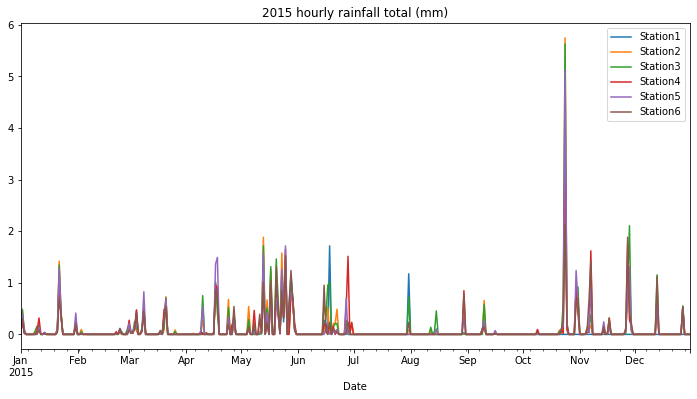

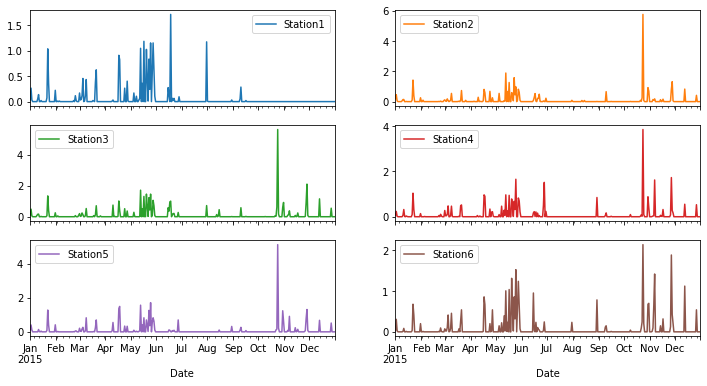

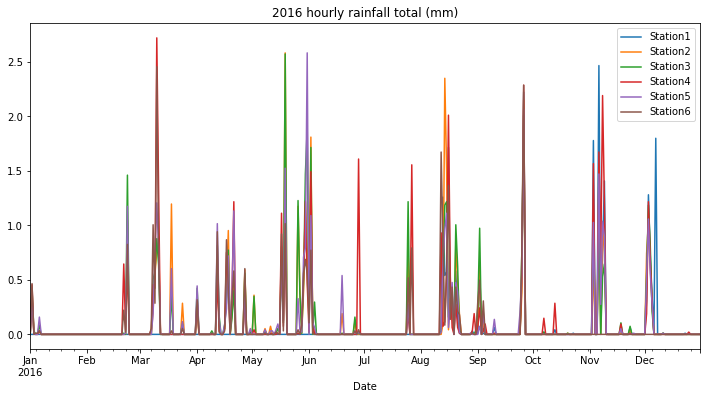

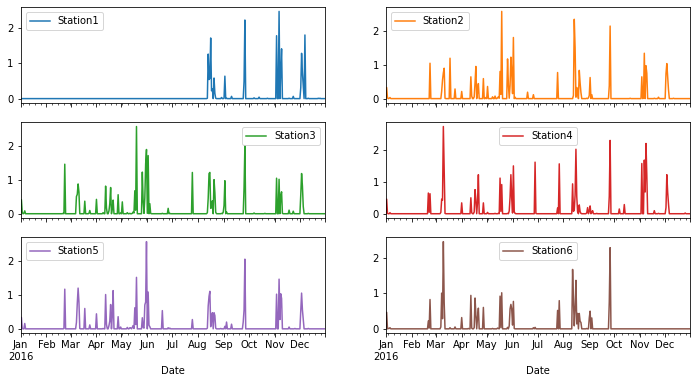

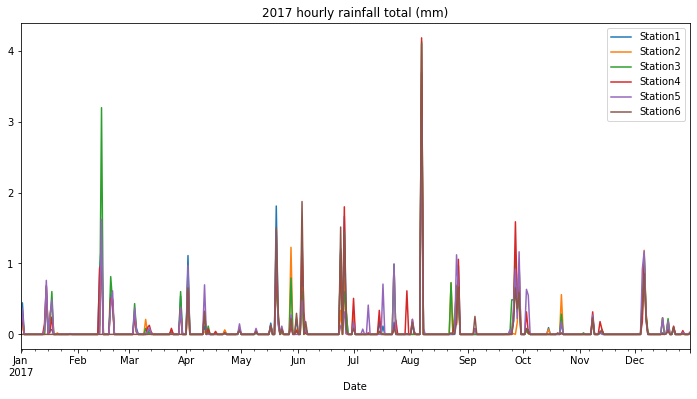

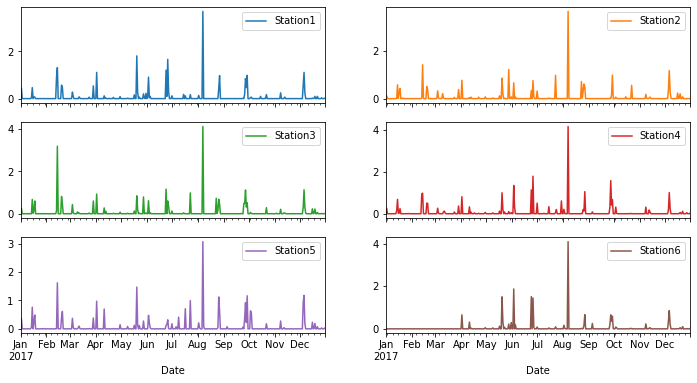

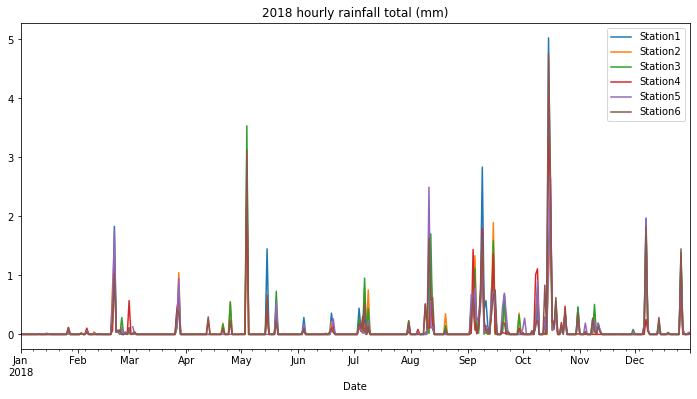

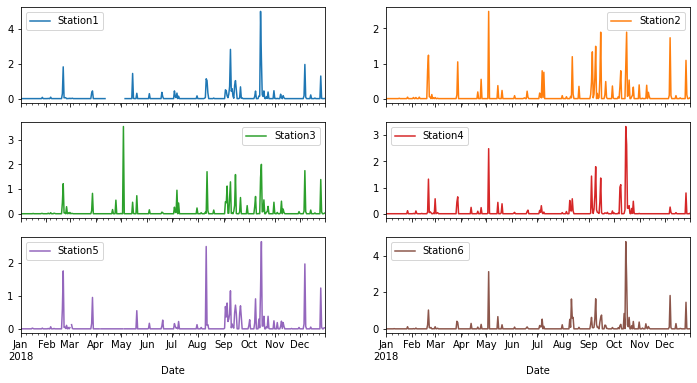

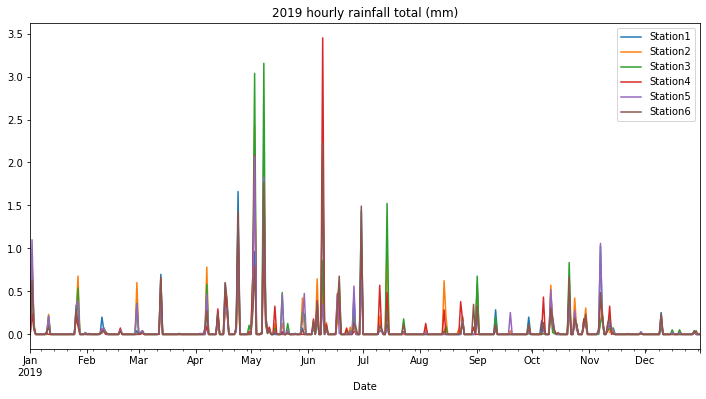

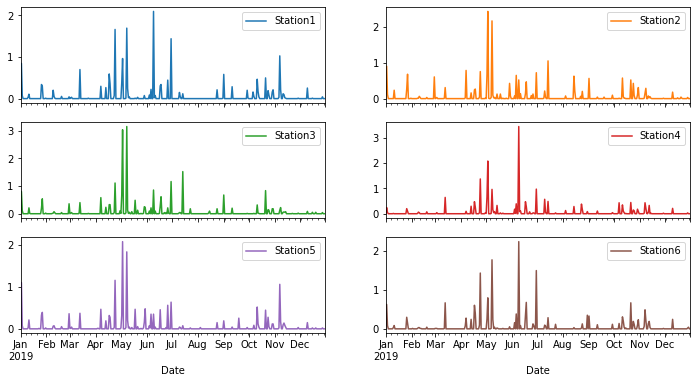

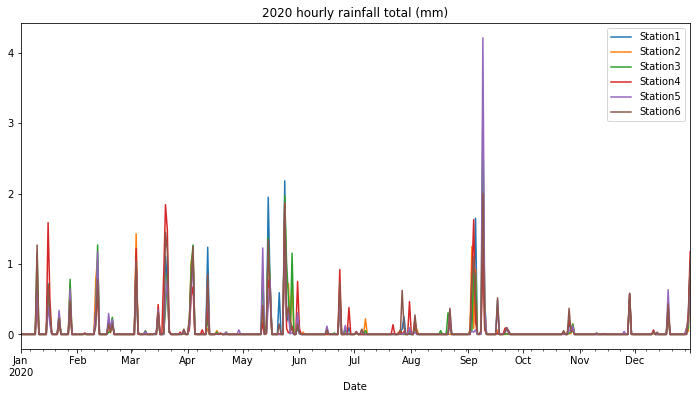

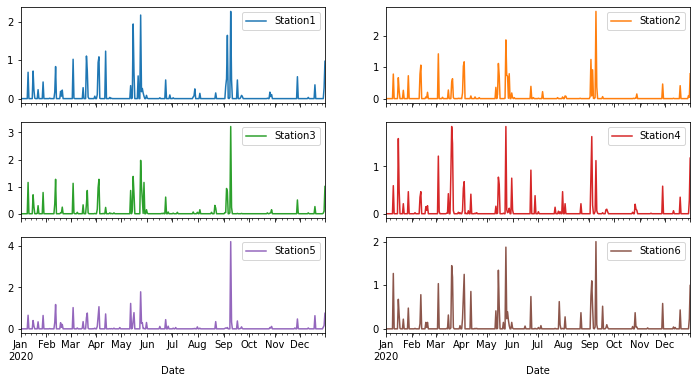

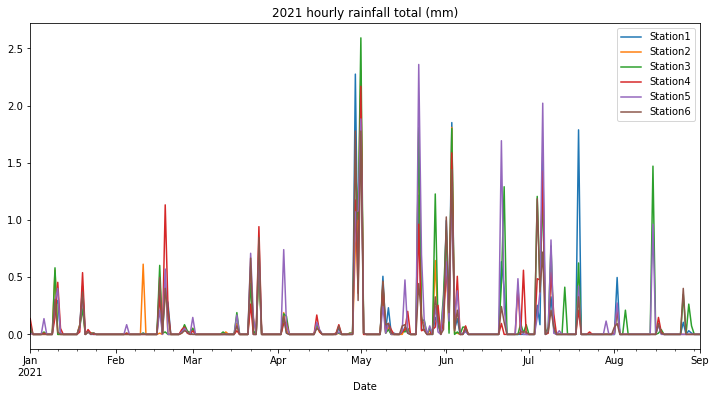

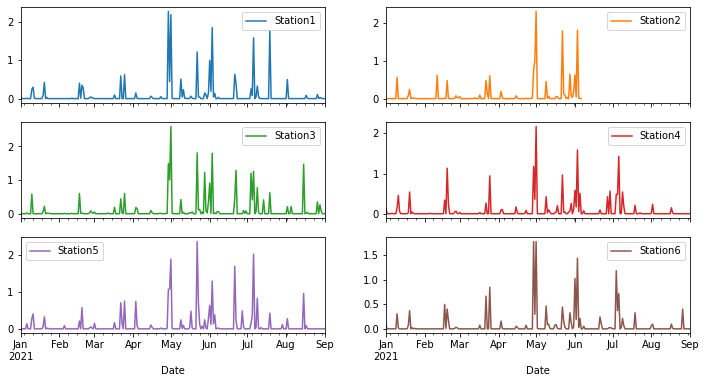

In [9]:
# For each year, plot the Ppt Data of all stations
plot_feature(df_Ppt, "hourly rainfall total (mm)")